Q1

a)

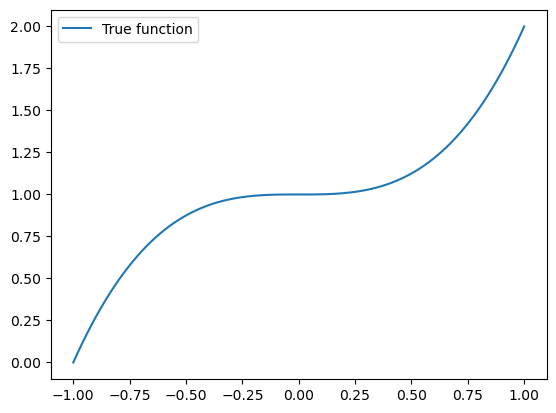

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-1, 1, 100)

y_true = x**3 + 1

plt.plot(x, y_true, label='True function')
plt.legend()
plt.show()

b)

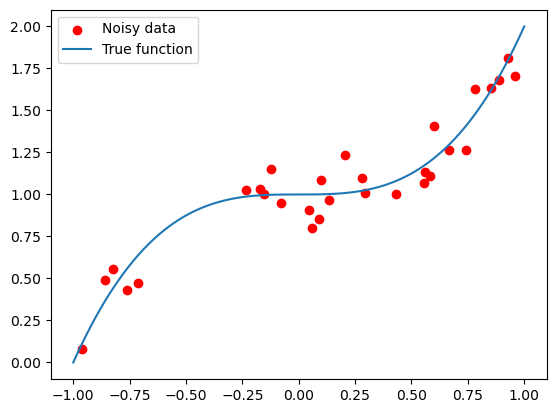

In [2]:
np.random.seed(0)

# Generate 30 random training points
X_train = np.random.uniform(-1, 1, 30)

# Generate the corresponding y values with some noise
y_train = X_train**3 + 1 + np.random.normal(0, 0.1, size=30)

plt.scatter(X_train, y_train, color='red', label='Noisy data')
plt.plot(x, y_true, label='True function')

plt.legend()
plt.show()

c)

In [3]:
from sklearn.linear_model import LinearRegression

x_train = X_train.reshape(-1, 1)

model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_train)

error = np.sum((y_train - y_pred)**2)

print("Linear Regression Error:", error)

Linear Regression Error: 0.7931370690641567


d)

Polynomial Regression Error: 0.24731836307891328


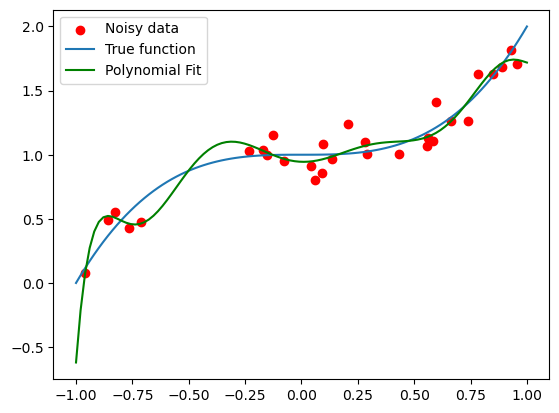

In [6]:
from sklearn.preprocessing import PolynomialFeatures

degree = 10

poly = PolynomialFeatures(degree)
x_poly = poly.fit_transform(x_train)

model_poly = LinearRegression()
model_poly.fit(x_poly, y_train)

# For plotting the polynomial fit
x_plot = poly.transform(x.reshape(-1, 1))
y_poly_pred = model_poly.predict(x_plot)

# Predict on the training data
y_poly_train_pred = model_poly.predict(x_poly)
error_poly = np.sum((y_train - y_poly_train_pred)**2)
print("Polynomial Regression Error:", error_poly)

plt.scatter(X_train, y_train, color='red', label='Noisy data')
plt.plot(x, y_true, label='True function')
plt.plot(x, y_poly_pred, label='Polynomial Fit', color='green')
plt.legend()
plt.show()

Q2

a)

In [7]:
import pandas as pd

df = pd.read_csv("pokemonregr.csv")

print(df.head())
print(df.columns)

   attack  defense  height_m  sp_attack  sp_defense  speed  weight_kg
0      30       35       0.3         20          20     45        2.9
1      20       55       0.7         25          25     30        9.9
2      45       50       1.1         90          80     70       32.0
3      35       30       0.3         20          20     50        3.2
4      25       50       0.6         25          25     35       10.0
Index(['attack', 'defense', 'height_m', 'sp_attack', 'sp_defense', 'speed',
       'weight_kg'],
      dtype='str')


b)

In [9]:
df = df.dropna()

# X = all columns except the last column
X = df.iloc[:, :-1].values

# y = last column
y = df.iloc[:, -1].values

model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


c)

In [10]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -56.394582146058
Coefficients: [ 3.77397553e-01  5.67721520e-01  5.35146255e+01  2.45998765e-02
  1.53453033e-01 -4.21539817e-01]


d)

In [12]:
feature_names = df.columns[:-1]

importance = np.abs(model.coef_)

for name, val in zip(feature_names, importance):
    print(name, val)

# 找最大
idx = np.argmax(importance)
print("Most important feature:", feature_names[idx])

attack 0.3773975531312692
defense 0.567721520111472
height_m 53.51462549445938
sp_attack 0.02459987654190663
sp_defense 0.1534530334919085
speed 0.4215398174361685
Most important feature: height_m


e)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model_scaled = LinearRegression()
model_scaled.fit(X_scaled, y)

print("Scaled Coefficients:", model_scaled.coef_)

importance_scaled = np.abs(model_scaled.coef_)

idx = np.argmax(importance_scaled)
print("Most important (scaled):", feature_names[idx])

Scaled Coefficients: [ 12.15337036  17.47803453  57.77623107   0.79121435   4.29529442
 -12.17646811]
Most important (scaled): height_m


Q3

a)

In [15]:
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("w3classif.csv")

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

model = LogisticRegression()
model.fit(X, y)

print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Weights: [[1.757695   1.75760916]]
Bias: [-4.65977334]


b)

In [16]:
x_test = np.array([[1.1, 1.1]])

prob = model.predict_proba(x_test)

print("P(y=1 | x') =", prob[0][1])

P(y=1 | x') = 0.3115380089231582


c)

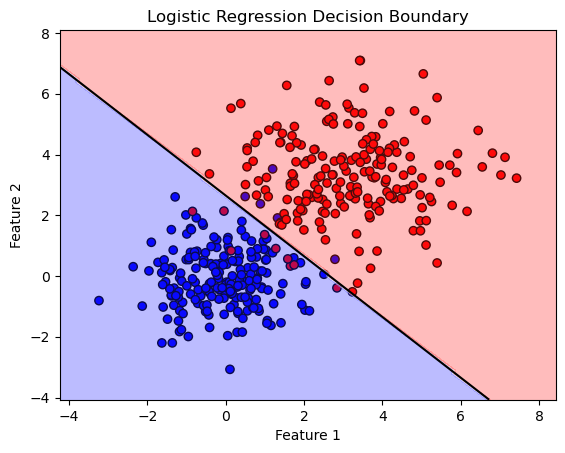

In [17]:
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr', edgecolors='k')

# Plot decision boundary
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 100),
    np.linspace(y_min, y_max, 100)
)

# Predict probabilities for each point in the grid
grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid)
Z = Z.reshape(xx.shape)

# Contour plot for decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')

# Plot the decision boundary
Z_prob = model.predict_proba(grid)[:,1].reshape(xx.shape)
plt.contour(xx, yy, Z_prob, levels=[0.5], colors='black')

plt.title("Logistic Regression Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()